# Foundations of AI: Applying Fundamental Mathematics in AI Problem Solving
### Alvyn Shibu

## Data Preprocessing

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import scipy.stats as st
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
def get_column_names(names_file):
    column_names = []
    with open(names_file, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith('@attribute'):
                parts = line.split()
                if len(parts) > 1:
                    name = parts[1]
                    column_names.append(name)
    return column_names

names_file ='data/communities.names'
column_names = get_column_names(names_file)

df = pd.read_csv("data/communities.data", sep = ",", names=column_names)
df.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


In [ ]:
# Print shape of dataset
df.shape

(1994, 128)

In [ ]:
# Separate features and target variable
x = df.drop("ViolentCrimesPerPop", axis=1)
y = df["ViolentCrimesPerPop"]

In [ ]:
# Print shape of data without target variable to ensure only the one column was dropped
x.shape

(1994, 127)

In [ ]:
# Print statistics of dataset
df.describe()

,state,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,...,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,28.683551,5.493982,0.057593,0.463395,0.179629,0.753716,0.153681,0.144022,0.424218,0.493867,...,0.215552,0.608892,0.535050,0.626424,0.651530,0.065231,0.232854,0.161685,0.094052,0.237979
std,16.397553,2.873694,0.126906,0.163717,0.253442,0.244039,0.208877,0.232492,0.155196,0.143564,...,0.231134,0.204329,0.181352,0.200521,0.198221,0.109459,0.203092,0.229055,0.240328,0.232985
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,3.000000,0.010000,0.350000,0.020000,0.630000,0.040000,0.010000,0.340000,0.410000,...,0.060000,0.470000,0.420000,0.520000,0.560000,0.020000,0.100000,0.020000,0.000000,0.070000
50%,34.000000,5.000000,0.020000,0.440000,0.060000,0.850000,0.070000,0.040000,0.400000,0.480000,...,0.130000,0.630000,0.540000,0.670000,0.700000,0.040000,0.170000,0.070000,0.000000,0.150000
75%,42.000000,8.000000,0.050000,0.540000,0.230000,0.940000,0.170000,0.160000,0.470000,0.540000,...,0.280000,0.777500,0.660000,0.770000,0.790000,0.070000,0.280000,0.190000,0.000000,0.330000
max,56.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Check for duplicated values
duplicates = df.duplicated()
print("Number of duplicate rows: ", duplicates.sum())

Number of duplicate rows:  0


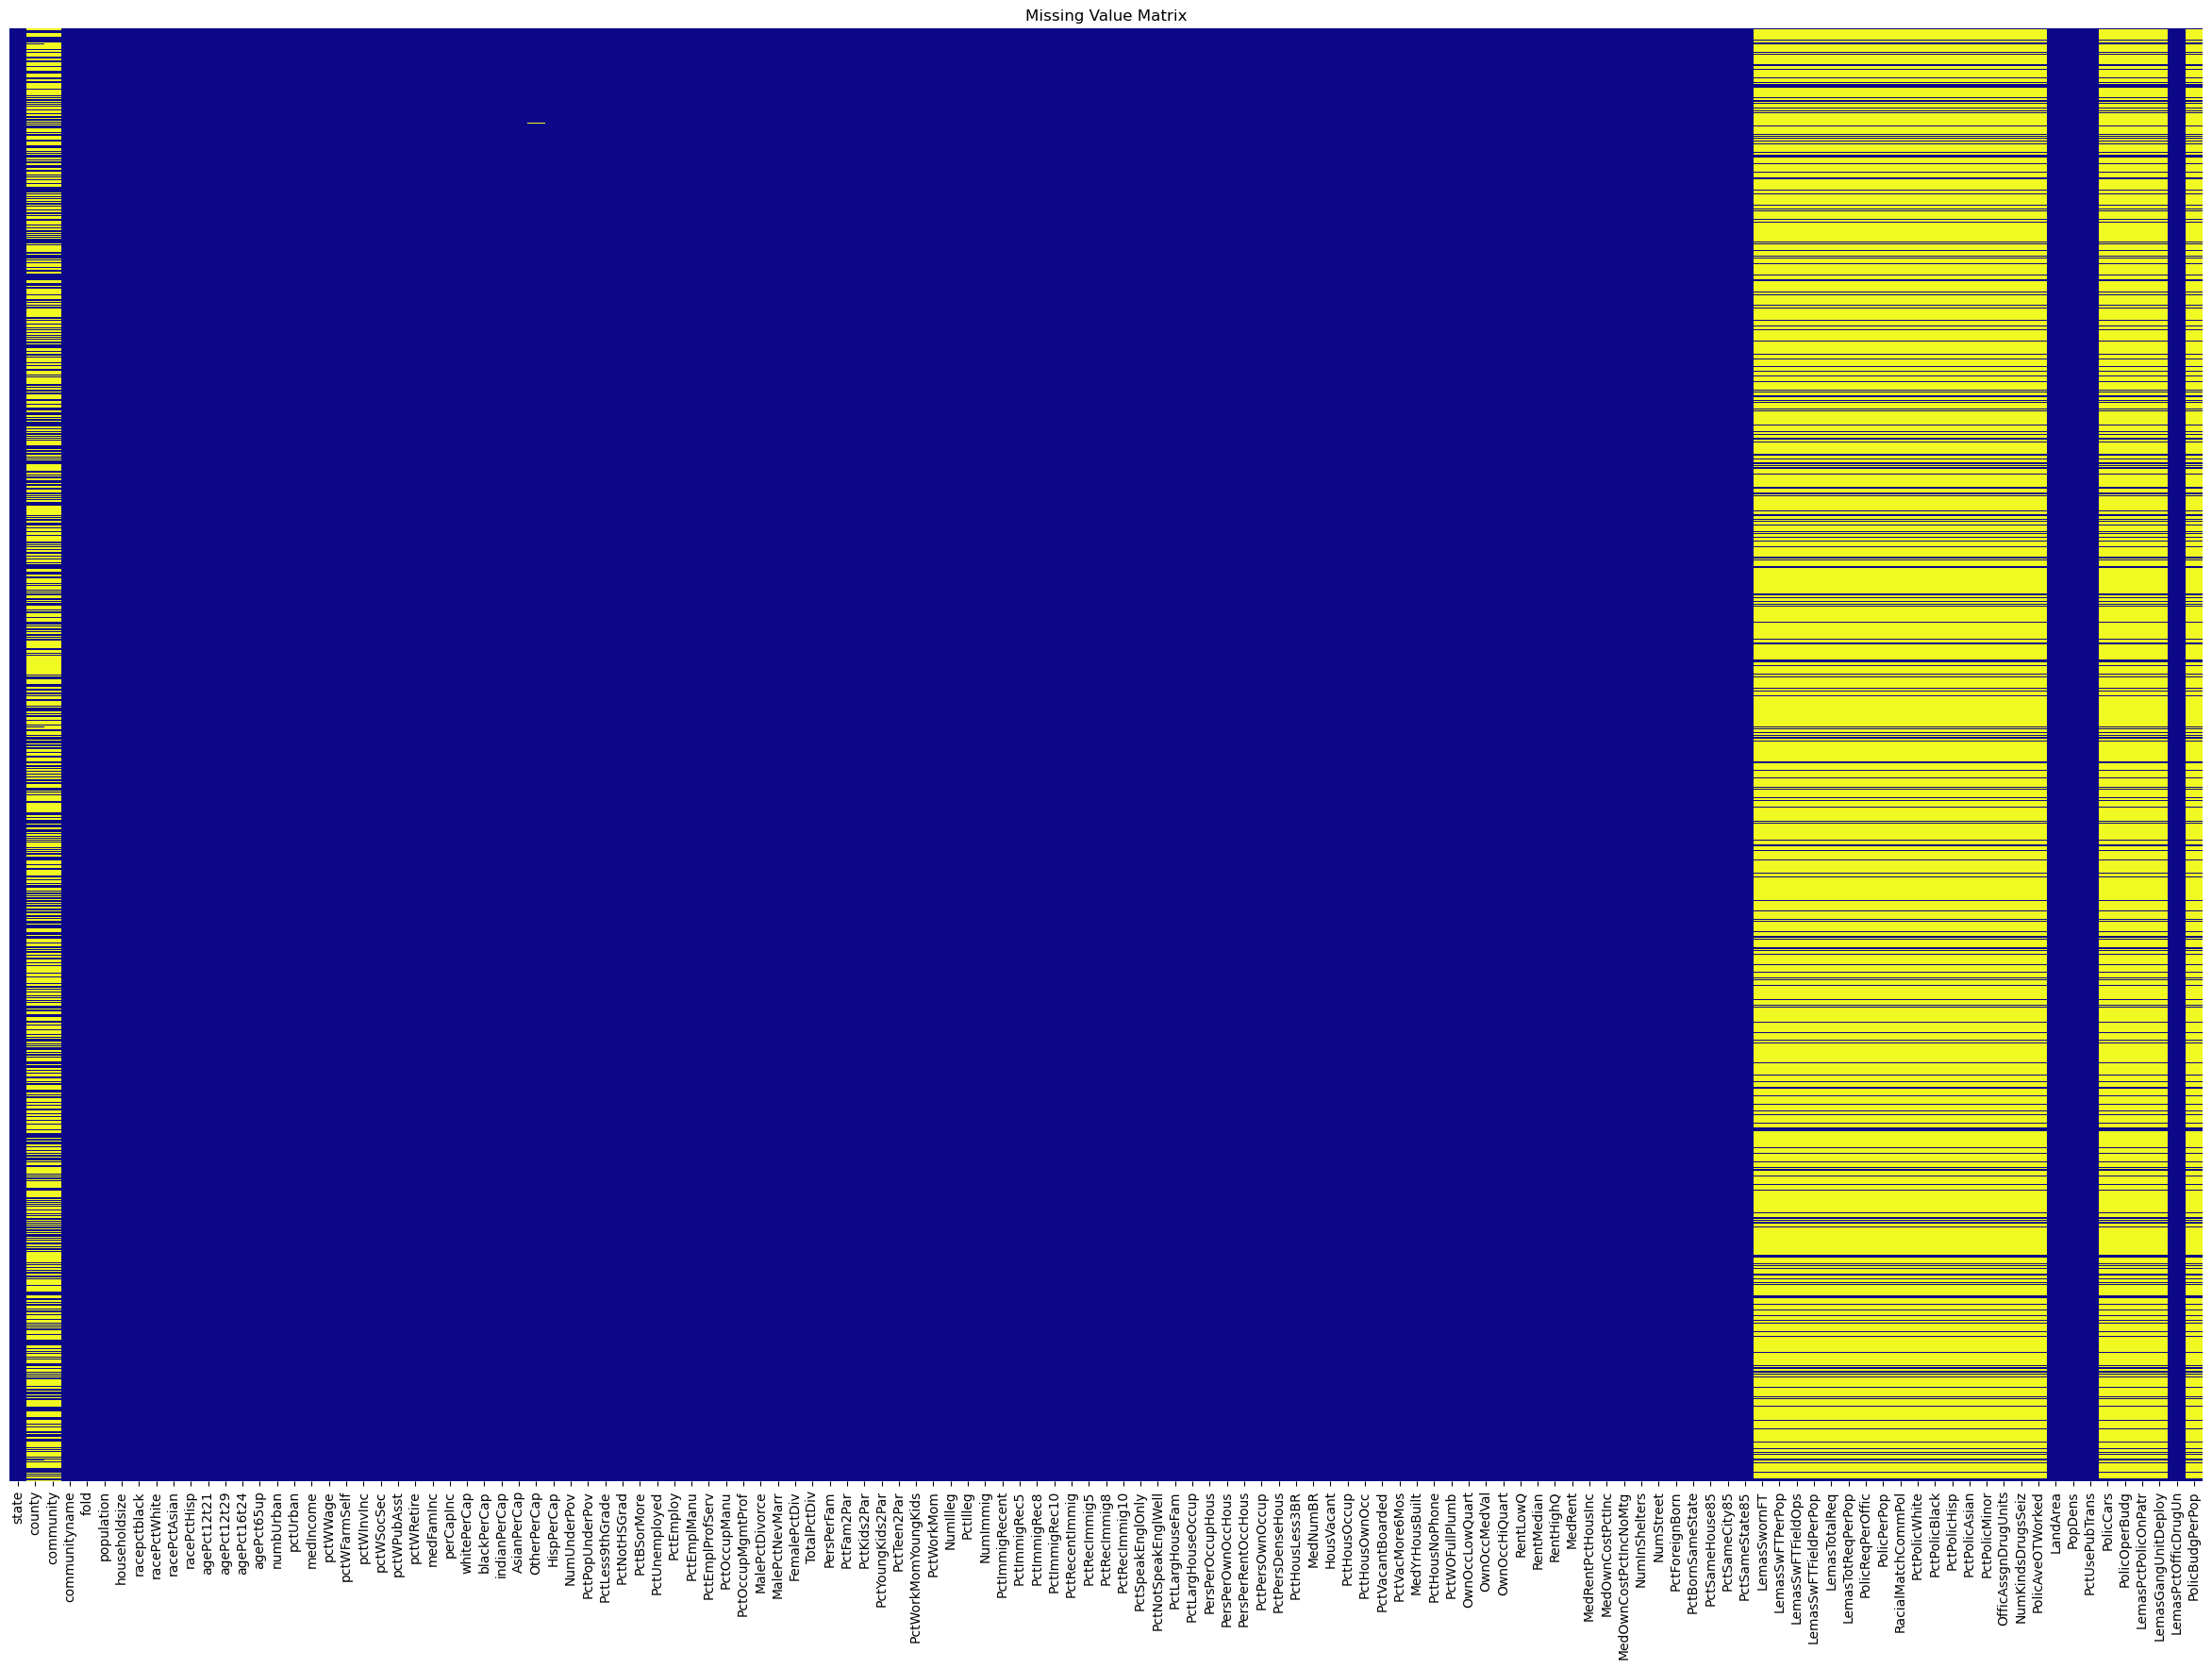

In [ ]:
# Visualise the amount of missing data from each column
# Create a variable to identify missing values
missing = x.eq('?')
plt.figure(figsize=(30, 20))
sns.heatmap(missing, cmap='plasma', cbar=False, yticklabels=False)
plt.title('Missing Value Matrix')
plt.show()

In [ ]:
# Check percentage of missing values in columns where values are missing
check_cols = ["county", "community", "LemasSwornFT", "LemasSwFTPerPop", "LemasSwFTFieldOps", "LemasSwFTFieldPerPop", "LemasTotalReq", "LemasTotReqPerPop","PolicReqPerOffic", "PolicPerPop", "RacialMatchCommPol", "PctPolicWhite", "PctPolicBlack", "PctPolicHisp", "PctPolicAsian", "PctPolicMinor", "OfficAssgnDrugUnits", "NumKindsDrugsSeiz", "PolicAveOTWorked", "PolicCars", "PolicOperBudg", "LemasPctPolicOnPatr", "LemasGangUnitDeploy", "PolicBudgPerPop"]
missing_pct = (df[check_cols].replace("?", np.nan).isna().mean() * 100)

print(missing_pct)

county                  58.876630
community               59.027081
LemasSwornFT            84.002006
LemasSwFTPerPop         84.002006
LemasSwFTFieldOps       84.002006
LemasSwFTFieldPerPop    84.002006
LemasTotalReq           84.002006
LemasTotReqPerPop       84.002006
PolicReqPerOffic        84.002006
PolicPerPop             84.002006
RacialMatchCommPol      84.002006
PctPolicWhite           84.002006
PctPolicBlack           84.002006
PctPolicHisp            84.002006
PctPolicAsian           84.002006
PctPolicMinor           84.002006
OfficAssgnDrugUnits     84.002006
NumKindsDrugsSeiz       84.002006
PolicAveOTWorked        84.002006
PolicCars               84.002006
PolicOperBudg           84.002006
LemasPctPolicOnPatr     84.002006
LemasGangUnitDeploy     84.002006
PolicBudgPerPop         84.002006
dtype: float64


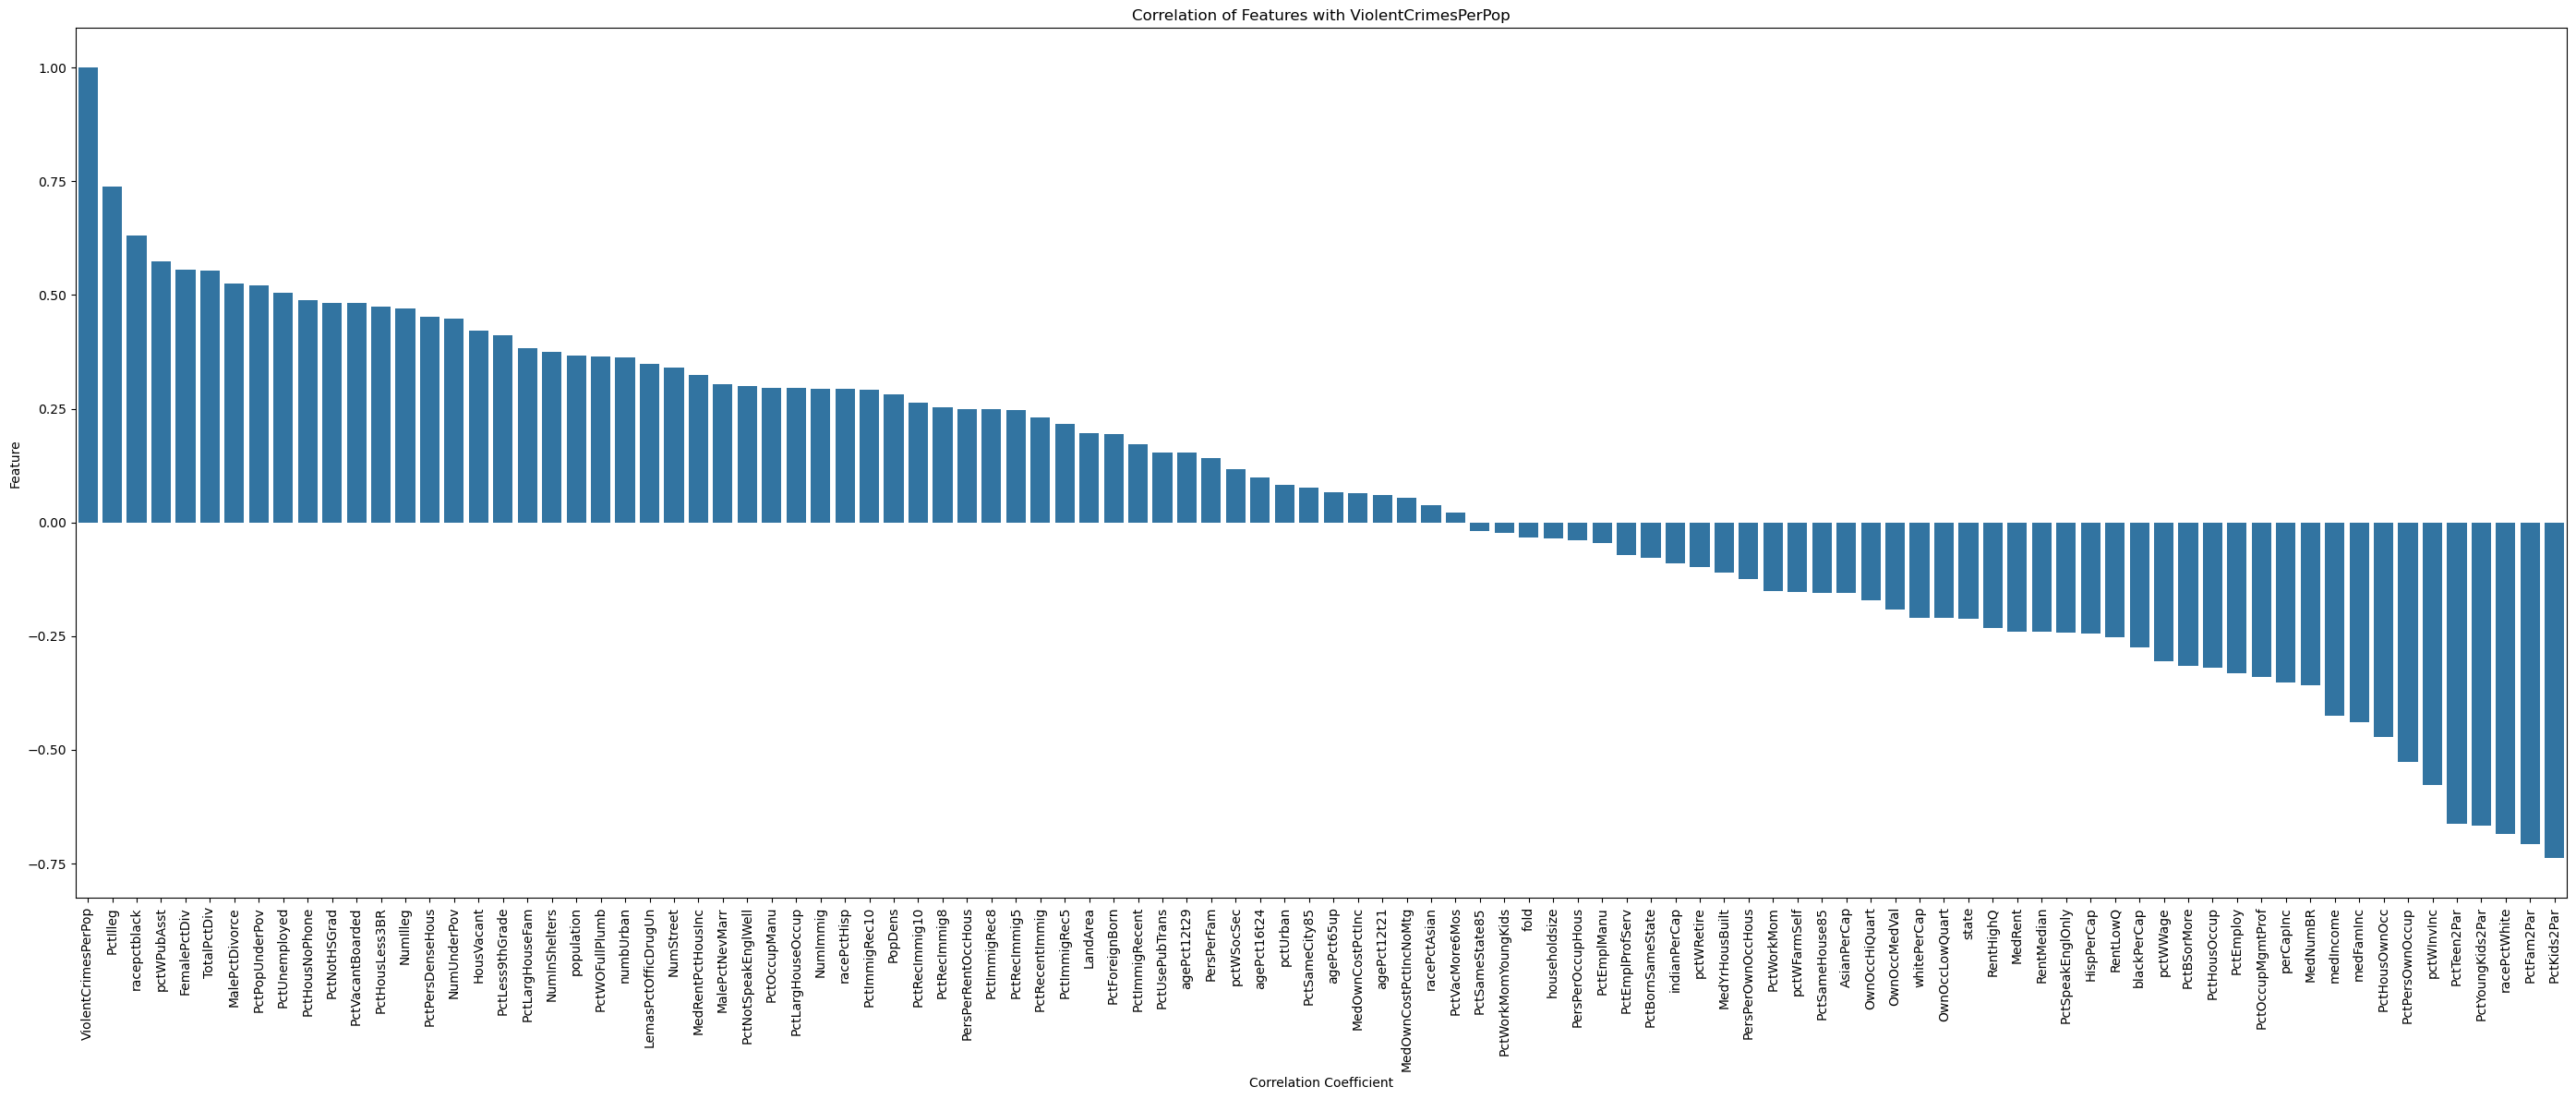

In [ ]:
corr_matrix = df.corr(numeric_only=True)["ViolentCrimesPerPop"].sort_values(ascending=False)
plt.figure(figsize=(28, 12))
sns.barplot(x=corr_matrix.index, y=corr_matrix.values)
plt.title("Correlation of Features with ViolentCrimesPerPop")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# Drop features that either: Have a large amount of missing values, are not measurements of community characteristics or could cause data leakage
x_clean = x.drop(["county", "state", "communityname", "community", "fold", "LemasSwornFT", "LemasSwFTPerPop", "LemasSwFTFieldOps", "LemasSwFTFieldPerPop", "LemasTotalReq", "LemasTotReqPerPop","PolicReqPerOffic", "PolicPerPop", "RacialMatchCommPol", "PctPolicWhite", "PctPolicBlack", "PctPolicHisp", "PctPolicAsian", "PctPolicMinor", "OfficAssgnDrugUnits", "NumKindsDrugsSeiz", "PolicAveOTWorked", "PolicCars", "PolicOperBudg", "LemasPctPolicOnPatr", "LemasGangUnitDeploy", "PolicBudgPerPop"], axis=1)

In [ ]:
# remove single row with missing value for "OtherPerCap" as visualised in heatmap
x_cleaned = x_clean[x_clean["OtherPerCap"] != '?']
# find out index of row which was dropped
missing_in_x = y.index.difference(x_cleaned.index)
print("Row in y but not in x: ", missing_in_x)
# remove corresponding row from target so that there is no shape mismatch
y_cleaned = y.drop(missing_in_x)

Row in y but not in x:  Int64Index([130], dtype='int64')


In [ ]:
print(y_cleaned.shape)

(1993,)


In [ ]:
print(x_cleaned.columns)

Index(['population', 'householdsize', 'racepctblack', 'racePctWhite',
       'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29',
       'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome',
       'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst',
       'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap',
       'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'HispPerCap',
       'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad',
       'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu',
       'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce',
       'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam',
       'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par',
       'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig',
       'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10',
       'PctRecentImmig', 'PctRecImmig5', 'PctRecI

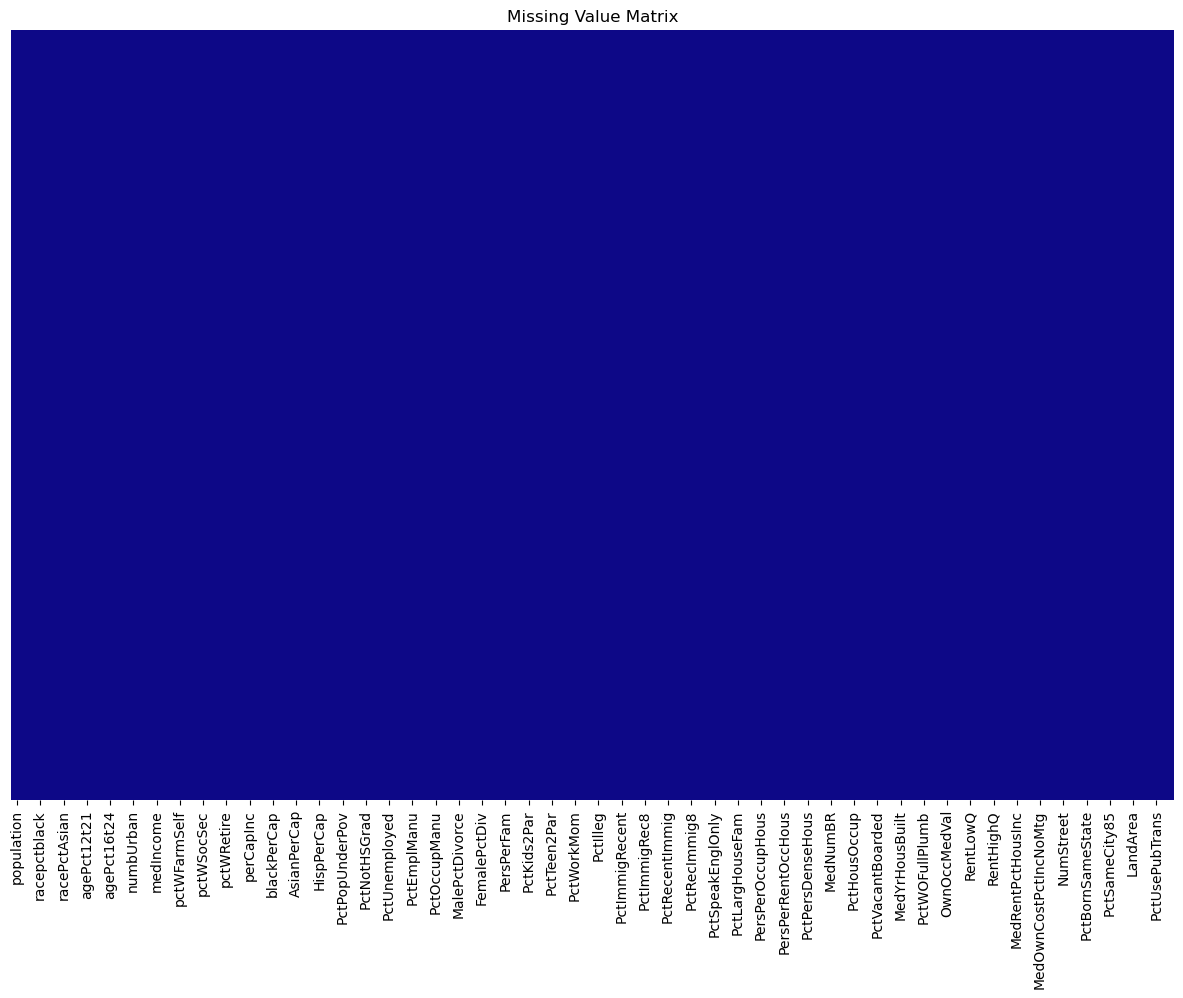

In [ ]:
# Visualise missing values again to ensure nothing was missed
missing2 = x_cleaned.eq('?')
plt.figure(figsize=(15, 10))
sns.heatmap(missing2, cmap='plasma', cbar=False, yticklabels=False)
plt.title('Missing Value Matrix')
plt.show()

## SVD Application

In [ ]:
# Use a StandardScaler to center and scale by std to preserve shape of variance distribution
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_cleaned)

In [ ]:
# Apply SVD
U, S, Vt = np.linalg.svd(x_scaled, full_matrices=False)
print(U)
print(S)
print(Vt)


[[ 0.00602226 -0.00560878 -0.0239697  ... -0.01410702 -0.00063016
  -0.00193846]
 [-0.00640404  0.00276453 -0.03156018 ... -0.00793577 -0.04773263
  -0.0719061 ]
 [-0.00947638 -0.01326223  0.00176648 ...  0.00105806 -0.01026429
  -0.00466199]
 ...
 [-0.01464441  0.00089047 -0.00729097 ...  0.00671199 -0.00568575
  -0.00108648]
 [ 0.00756315  0.01866241 -0.0115281  ... -0.04105088 -0.02013614
  -0.02200073]
 [-0.01479973  0.05548725  0.02768575 ...  0.01419066  0.02920863
  -0.0163193 ]]
[224.01382922 183.09096343 136.13506204 122.67191484 105.97106321
  91.50686293  80.36027102  76.3291259   64.21967165  56.10021967
  54.99353702  53.60092509  52.09942999  45.31507911  43.72338881
  42.16553852  41.45176403  38.59910248  37.22511042  35.77727257
  35.27092495  34.48020166  32.69029763  32.20047157  31.14668936
  30.97285709  30.44846409  29.3333354   28.32788635  27.79775972
  26.96280342  26.63491067  25.90177771  25.05153661  24.07043852
  23.27412307  22.58839096  22.26582076  21.97

In [ ]:
# Calculate explained and cumulative variance
explained_variance = (S ** 2) / np.sum(S ** 2)
cumulative_variance = np.cumsum(explained_variance)

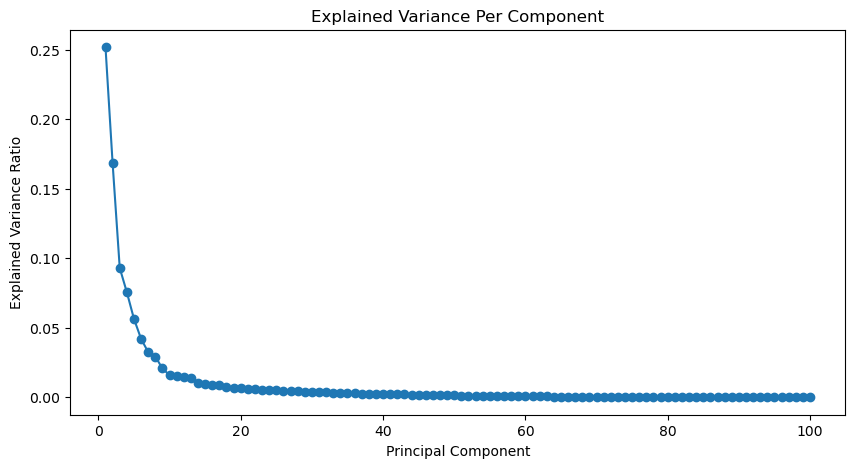

In [ ]:
# Plot the explained variance
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(S)+1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Per Component")
plt.show()

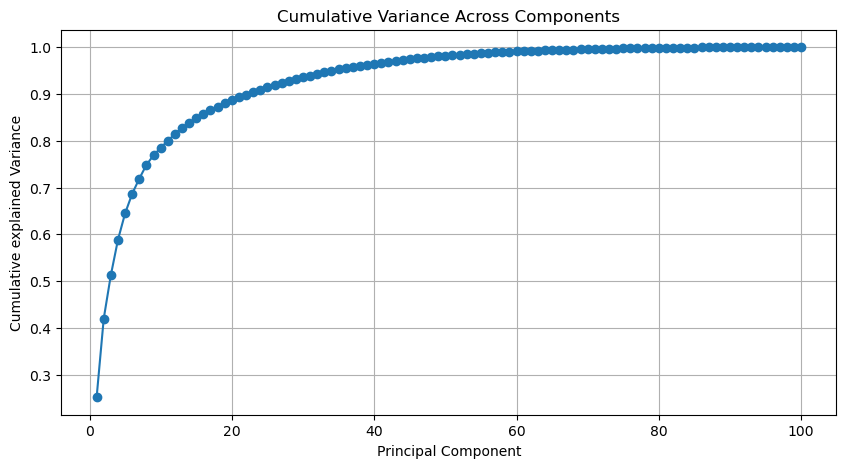

In [ ]:
# Plot the cumulative variance
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(S)+1), cumulative_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative explained Variance")
plt.title("Cumulative Variance Across Components")
plt.grid(True)
plt.show()

In [ ]:
# Select top 'k' largest singular values in Σ
k = np.argmax(cumulative_variance >= 0.95) + 1
k

35

In [ ]:
print("Explained variance (95%): ", cumulative_variance[k-1])

Explained variance (95%):  0.9524230592843378


In [ ]:
# Principal components are the right singular vectors (Vt)
# Reduce data to 'k' dimensions
x_reduced = np.dot(x_scaled, Vt.T[:, :k])
x_reduced

array([[ 1.34907052e+00, -1.02691714e+00, -3.26311623e+00, ...,
        -1.07429322e-01,  1.13390813e-01,  3.31036422e-02],
       [-1.43459318e+00,  5.06159763e-01, -4.29644699e+00, ...,
        -1.21267131e-01,  1.78065925e-02,  8.07931192e-01],
       [-2.12284046e+00, -2.42819495e+00,  2.40479796e-01, ...,
         2.78892805e-01, -6.49240988e-01, -8.46249000e-02],
       ...,
       [-3.28054955e+00,  1.63036351e-01, -9.92557265e-01, ...,
         3.84233225e-01, -1.50400388e-03,  8.84274051e-02],
       [ 1.69424955e+00,  3.41691832e+00, -1.56937877e+00, ...,
         1.25580114e-01, -2.16701621e-01,  6.89680842e-01],
       [-3.31534510e+00,  1.01592132e+01,  3.76900167e+00, ...,
        -6.49928380e-01, -3.26953655e-01, -3.54052379e-01]])

In [ ]:
# Output the shape of the reduced data after applying svd
print(x_reduced.shape)

(1993, 35)


## Exploratory Data Analysis

In [ ]:
# Output the features that contribute the most and least to each component
contributions = pd.DataFrame(Vt.T[:, :k], index=x_cleaned.columns, columns=[f"PC{i+1}" for i in range(k)])

for i in range(k):
    print(f"\nTop contributing features to PC{i+1}: ")
    print(contributions.iloc[:, i].sort_values(ascending=False).head(10))
    print("\nMost negative contributors: ")
    print(contributions.iloc[:, i].sort_values().head(10))


Top contributing features to PC1: 
medFamInc           0.182929
medIncome           0.181647
PctKids2Par         0.174699
pctWInvInc          0.174152
PctFam2Par          0.171902
PctYoungKids2Par    0.170946
perCapInc           0.169158
PctTeen2Par         0.150731
MedRent             0.149226
whitePerCap         0.147815
Name: PC1, dtype: float64

Most negative contributors: 
PctPopUnderPov    -0.173255
pctWPubAsst       -0.164001
PctHousNoPhone    -0.163531
PctNotHSGrad      -0.161310
PctUnemployed     -0.158060
PctLess9thGrade   -0.145171
PctIlleg          -0.144534
PctOccupManu      -0.133915
TotalPctDiv       -0.129078
PctHousLess3BR    -0.127764
Name: PC1, dtype: float64

Top contributing features to PC2: 
PctRecImmig10          0.219149
PctRecImmig8           0.219093
PctRecImmig5           0.216955
PctRecentImmig         0.214450
PctForeignBorn         0.212574
PctNotSpeakEnglWell    0.187471
PctPersDenseHous       0.174681
racePctAsian           0.167428
racePctHisp         

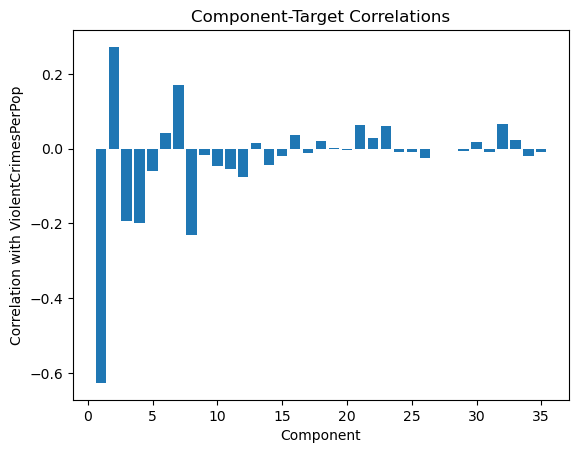

In [ ]:
# Creates a visual that correlates each component with the target
corrs = [np.corrcoef(x_reduced[:, i], y_cleaned)[0, 1] for i in range(k)]

plt.bar(range(1, k+1), corrs)
plt.xlabel("Component")
plt.ylabel("Correlation with ViolentCrimesPerPop")
plt.title("Component-Target Correlations")
plt.show()

In [ ]:
# Create Analysis DataFrame
cols = [f"PC{i+1}" for i in range(x_reduced.shape[1])]
df_svd = pd.DataFrame(x_reduced, columns=cols)
df_svd['ViolentCrimesPerPop'] = y_cleaned.values

In [ ]:
# Examine the distribution and summary statistics
print("Summary Statistics")
print(df_svd['ViolentCrimesPerPop'].describe())

Summary Statistics
count    1993.000000
mean        0.237983
std         0.233043
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: ViolentCrimesPerPop, dtype: float64


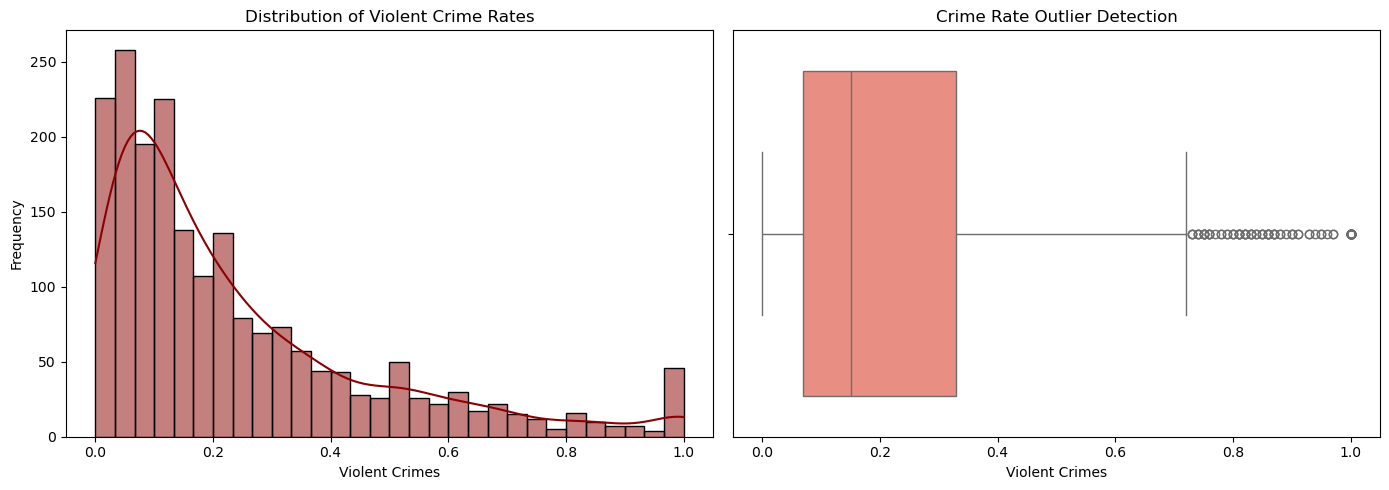

In [ ]:
plt.figure(figsize=(14, 5))

# Target Variable Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_svd['ViolentCrimesPerPop'], bins=30, kde=True, color='darkred')
plt.title('Distribution of Violent Crime Rates')
plt.xlabel('Violent Crimes')
plt.ylabel('Frequency')

# Boxplot to check for Outliers in the Target
plt.subplot(1, 2, 2)
sns.boxplot(x=df_svd['ViolentCrimesPerPop'], color='salmon')
plt.title('Crime Rate Outlier Detection')
plt.xlabel('Violent Crimes')

plt.tight_layout()
plt.show()

In [ ]:
# Shapiro-Wilk Normality Test
stat, p_val_norm = st.shapiro(df_svd['ViolentCrimesPerPop'])
print(f"\nShapiro-Wilk Normality Test: Statistic={stat:.4f}, P-Value={p_val_norm:.4e}")
if p_val_norm < 0.05:
    print("The target variable is NOT normally distributed (Reject H0).")
else:
    print("The target variable looks normally distributed.")



Shapiro-Wilk Normality Test: Statistic=0.8216, P-Value=1.7167e-42
The target variable is NOT normally distributed (Reject H0).


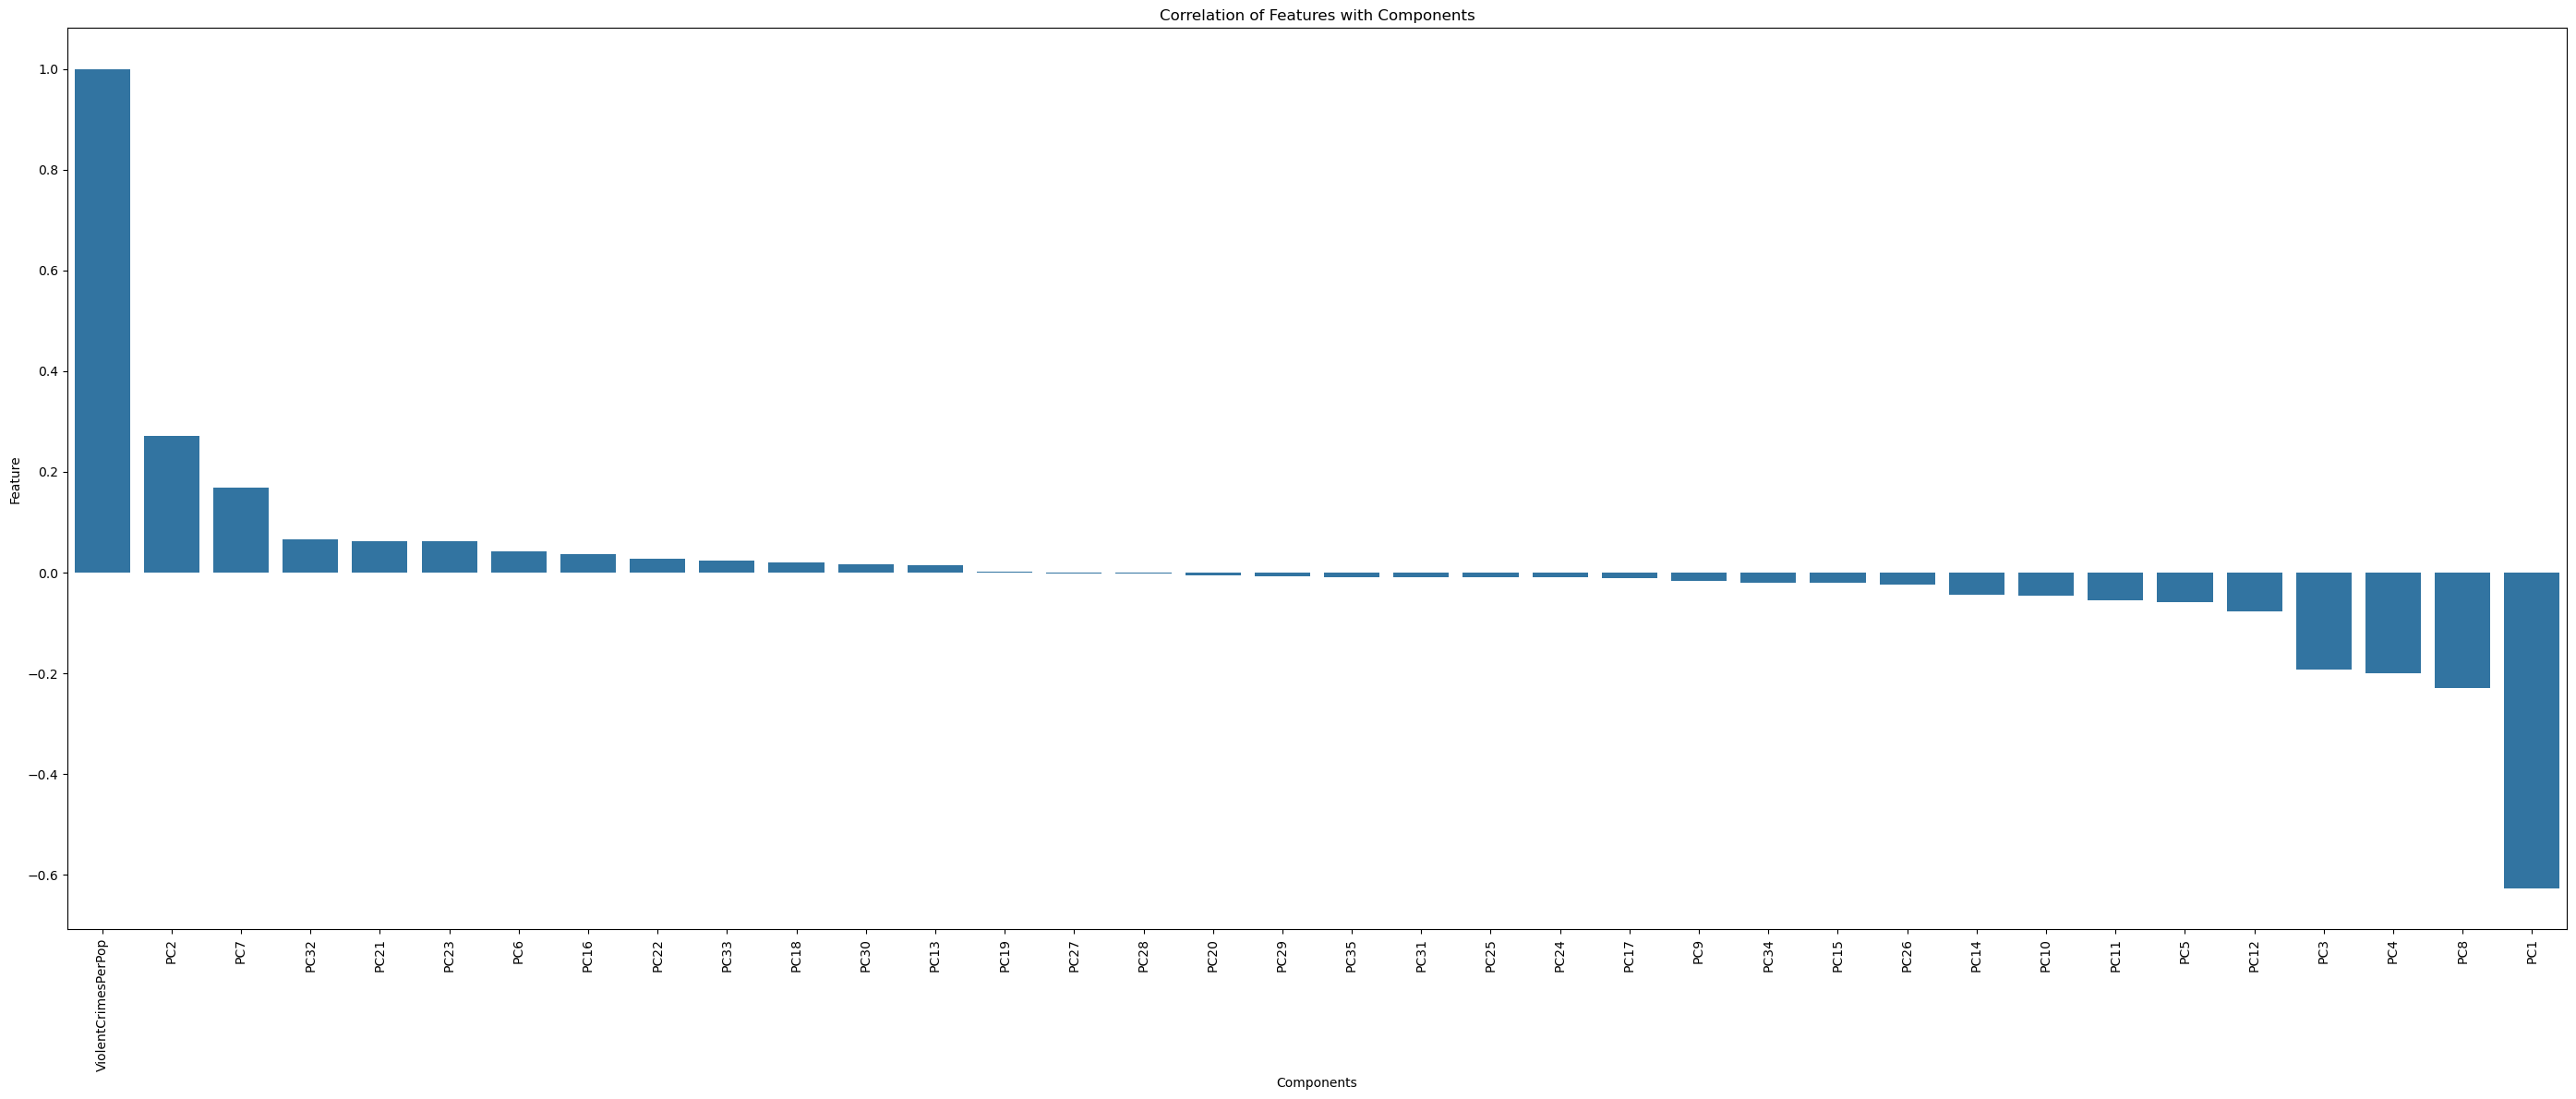

In [ ]:
# Bivariate & Multivariate Analysis (Correlations)
corr_matrix = df_svd.corr(numeric_only=True)["ViolentCrimesPerPop"].sort_values(ascending=False)
plt.figure(figsize=(28, 12))
sns.barplot(x=corr_matrix.index, y=corr_matrix.values)
plt.title("Correlation of Features with Components")
plt.xlabel("Components")
plt.ylabel("Feature")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



Top Correlated Component: PC2 (Corr: 0.2721)


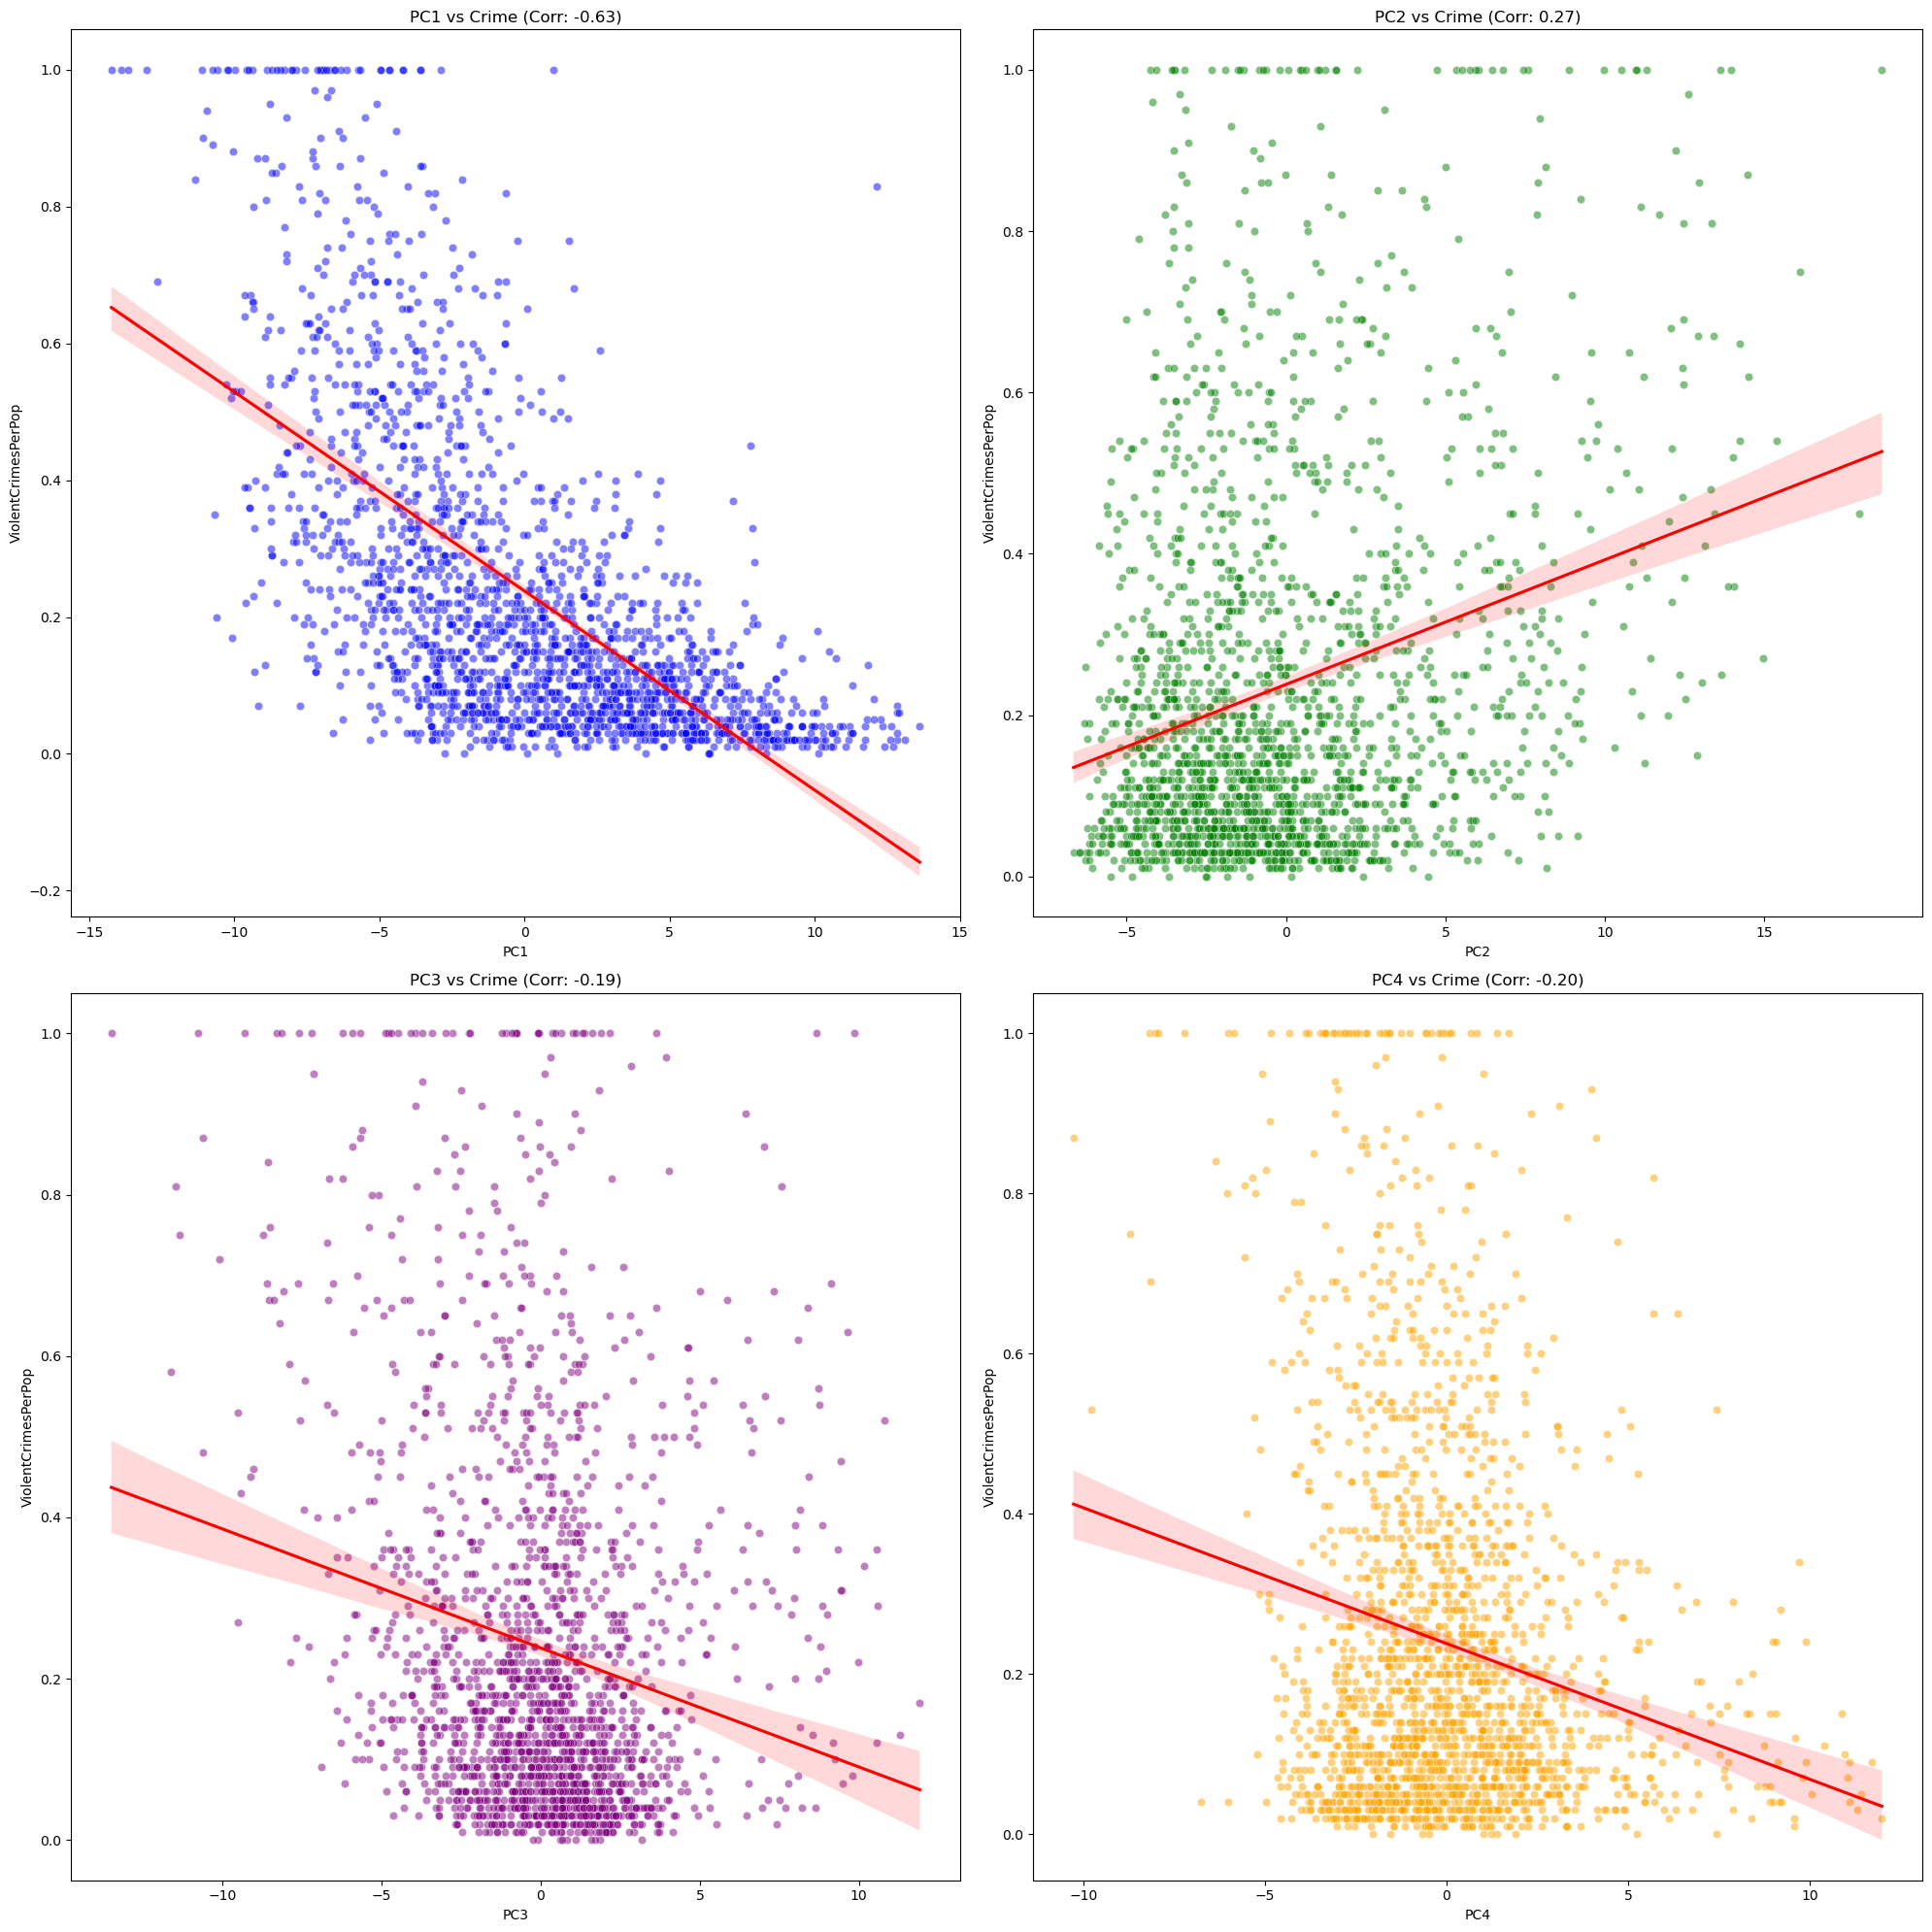

In [ ]:
# Visualizing the linearity between the best predictors and the target
target_corr = df_svd.corrwith(df_svd['ViolentCrimesPerPop']).drop('ViolentCrimesPerPop')
print(f"\nTop Correlated Component: {target_corr.idxmax()} (Corr: {target_corr.max():.4f})")

fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# PC1 vs Crime
sns.scatterplot(x=df_svd['PC1'], y=df_svd['ViolentCrimesPerPop'], alpha=0.5, ax=axes[0,0], color='blue')
sns.regplot(x=df_svd['PC1'], y=df_svd['ViolentCrimesPerPop'], scatter=False, ax=axes[0,0], color='red')
axes[0,0].set_title(f'PC1 vs Crime (Corr: {target_corr["PC1"]:.2f})')

# PC2 vs Crime
sns.scatterplot(x=df_svd['PC2'], y=df_svd['ViolentCrimesPerPop'], alpha=0.5, ax=axes[0,1], color='green')
sns.regplot(x=df_svd['PC2'], y=df_svd['ViolentCrimesPerPop'], scatter=False, ax=axes[0,1], color='red')
axes[0,1].set_title(f'PC2 vs Crime (Corr: {target_corr["PC2"]:.2f})')

sns.scatterplot(x=df_svd['PC3'], y=df_svd['ViolentCrimesPerPop'], alpha=0.5, ax=axes[1,0], color='purple')
sns.regplot(x=df_svd['PC3'], y=df_svd['ViolentCrimesPerPop'], scatter=False, ax=axes[1,0], color='red')
axes[1,0].set_title(f'PC3 vs Crime (Corr: {target_corr["PC3"]:.2f})')

sns.scatterplot(x=df_svd['PC4'], y=df_svd['ViolentCrimesPerPop'], alpha=0.5, ax=axes[1,1], color='orange')
sns.regplot(x=df_svd['PC4'], y=df_svd['ViolentCrimesPerPop'], scatter=False, ax=axes[1,1], color='red')
axes[1,1].set_title(f'PC4 vs Crime (Corr: {target_corr["PC4"]:.2f})')

plt.tight_layout()
plt.show()

In [ ]:
# Hypothesis Testing (Independent T-Test)
# H0: There is no difference in crime rates between High and Low PC1 communities
print("\nHypothesis Testing (T-Test)")
pc1_median = df_svd['PC1'].median()
group_high = df_svd[df_svd['PC1'] > pc1_median]['ViolentCrimesPerPop']
group_low = df_svd[df_svd['PC1'] <= pc1_median]['ViolentCrimesPerPop']

t_stat, p_val = st.ttest_ind(group_high, group_low, equal_var=False)
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_val:.4e}")
if p_val < 0.05:
    print("Reject Null Hypothesis (Significant difference found)")
else:
    print("Fail to Reject Null Hypothesis")


Hypothesis Testing (T-Test)
T-Statistic: -26.9073, P-Value: 7.9652e-128
Reject Null Hypothesis (Significant difference found)


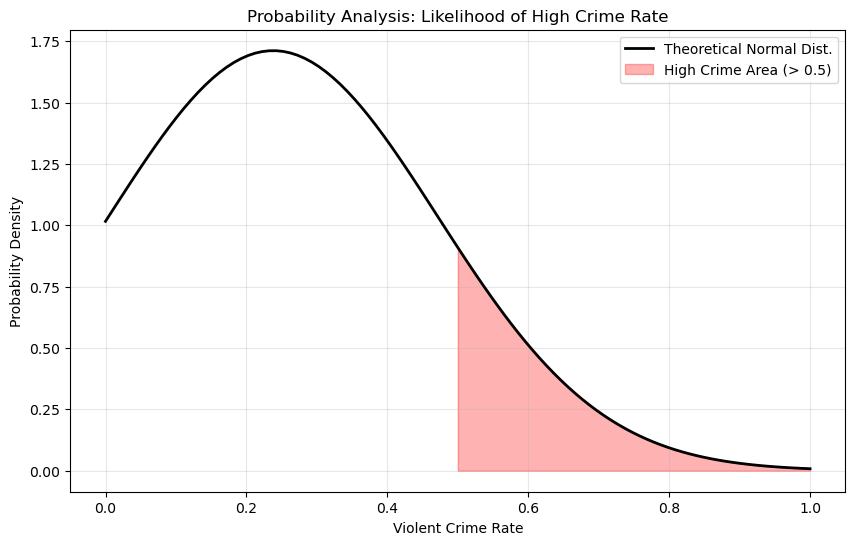


Theoretical Probability (Crime > 0.5): 0.1304
Empirical Probability (Actual Data):      0.1390


In [ ]:
# Probability Analysis
# Calculate the probability of Crime Rate > 0.5
target_mean = df_svd['ViolentCrimesPerPop'].mean()
target_std = df_svd['ViolentCrimesPerPop'].std()
threshold = 0.5

# Visualization
x_range = np.linspace(df_svd['ViolentCrimesPerPop'].min(), df_svd['ViolentCrimesPerPop'].max(), 100)
pdf_values = st.norm.pdf(x_range, loc=target_mean, scale=target_std)

plt.figure(figsize=(10, 6))
plt.plot(x_range, pdf_values, 'k-', linewidth=2, label='Theoretical Normal Dist.')
x_fill = np.linspace(threshold, x_range.max(), 100)
y_fill = st.norm.pdf(x_fill, loc=target_mean, scale=target_std)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label=f'High Crime Area (> {threshold})')
plt.title('Probability Analysis: Likelihood of High Crime Rate')
plt.xlabel('Violent Crime Rate')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculation
prob_theoretical = 1 - st.norm.cdf(threshold, loc=target_mean, scale=target_std)
prob_actual = len(df_svd[df_svd['ViolentCrimesPerPop'] > threshold]) / len(df_svd)

print(f"\nTheoretical Probability (Crime > {threshold}): {prob_theoretical:.4f}")
print(f"Empirical Probability (Actual Data):      {prob_actual:.4f}")

## Model Optimisation

### Neural Network

In [ ]:
#Data preparation
x_data = np.array(x_reduced)
y_data = np.array(y_cleaned).reshape(-1, 1)

# Split Data (80% Train/20% Test)
x_train_full, x_test, y_train_full, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Helper functions
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def cost_function_mse(y, y_hat):
    m = len(y)
    if np.isnan(y_hat).any(): return float('inf')
    return (1 / (2 * m)) * np.sum((y_hat - y)**2)

In [ ]:
# Model Implementations
# Linear Regression
def train_linear_scratch(x, y, alpha=0.01, num_iterations=1000):
    num_samples, num_features = x.shape
    np.random.seed(42)

    W = np.random.randn(num_features, 1) * 0.01
    b = np.zeros((1, 1))

    cost_history = []

    # Gradient descent loop
    for i in range(num_iterations):

        # Forward propagation
        y_hat = np.dot(x, W) + b

        # Backpropogation
        dJ_dz = (y_hat - y)
        dJ_dW = (1/num_samples) * np.dot(x.T, dJ_dz)
        dJ_db = (1/num_samples) * np.sum(dJ_dz, axis=0, keepdims=True)

        # Update params
        W -= alpha * dJ_dW
        b -= alpha * dJ_db

        if i % 100 == 0:
            cost_history.append(cost_function_mse(y, y_hat))

    return {"W": W, "b": b}, cost_history

def predict_linear(x, params):
    return np.dot(x, params["W"]) + params["b"]

# Neural Network
def train_nn_scratch(x, y, hidden_nodes=5, alpha=0.01, num_iterations=1000):
    num_samples, num_features = x.shape
    np.random.seed(42)

    W1 = np.random.randn(num_features, hidden_nodes) * 0.01
    b1 = np.zeros((1, hidden_nodes))
    W2 = np.random.randn(hidden_nodes, 1) * 0.01
    b2 = np.zeros((1, 1))

    cost_history = []

    for i in range(num_iterations):

        # Forward propagation
        z1 = np.dot(x, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        y_hat = z2

        dJ_dz2 = (y_hat - y)
        dJ_dW2 = (1/num_samples) * np.dot(a1.T, dJ_dz2)
        dJ_db2 = (1/num_samples) * np.sum(dJ_dz2, axis=0, keepdims=True)

        dz2_da1 = np.dot(dJ_dz2, W2.T)
        dJ_dz1 = dz2_da1 * sigmoid_derivative(z1)
        dJ_dW1 = (1/num_samples) * np.dot(x.T, dJ_dz1)
        dJ_db1 = (1/num_samples) * np.sum(dJ_dz1, axis=0, keepdims=True)

        # Update params
        W1 -= alpha * dJ_dW1
        b1 -= alpha * dJ_db1
        W2 -= alpha * dJ_dW2
        b2 -= alpha * dJ_db2

        if i % 100 == 0:
            cost_history.append(cost_function_mse(y, y_hat))

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}, cost_history

def predict_nn(x, params):
    z1 = np.dot(x, params["W1"]) + params["b1"]
    a1 = sigmoid(z1)
    z2 = np.dot(a1, params["W2"]) + params["b2"]
    return z2


Finding Optimal Parameters
Tuning Linear Regression
Best LR Params: Alpha=0.005
2. Tuning Neural Network
Best NN Params: Nodes=5, Alpha=0.7


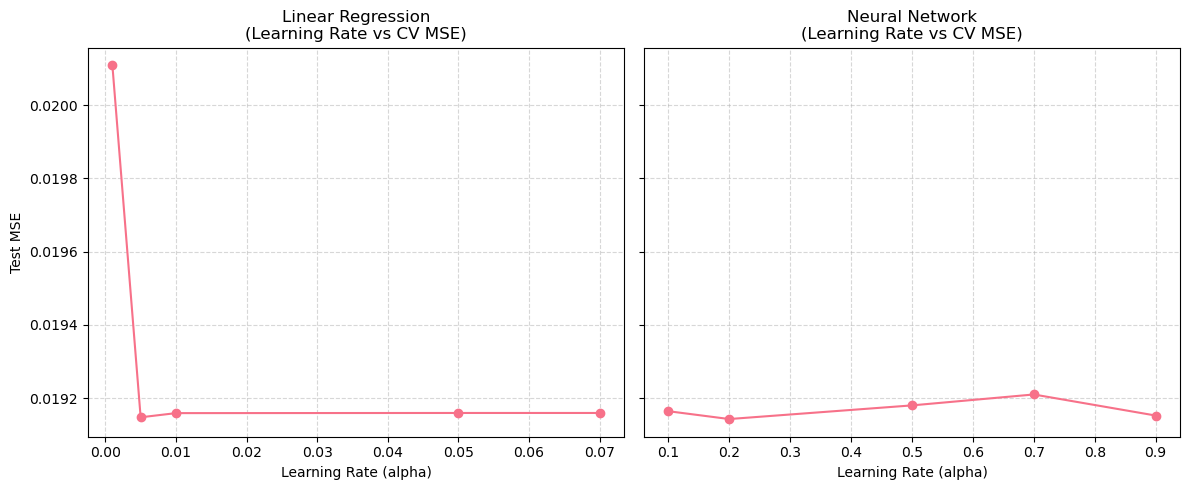

In [ ]:
# Hyperparameter refinement
print("\nFinding Optimal Parameters")

lr_search_alphas = [0.001, 0.005, 0.01, 0.05, 0.07]
nn_search_alphas = [0.1, 0.2, 0.5, 0.7, 0.9]
search_nodes = [4, 5, 6]
lr_tuning_curve = []
nn_tuning_curve = []

# Tune LinReg
print("Tuning Linear Regression")

best_lr_alpha = None
best_lr_cv_mse = float('inf')
lr_tuning_curve = []

for alpha in lr_search_alphas:
    fold_errors = []

    for train_idx, val_idx in kf.split(x_train_full):
        X_tr = x_train_full[train_idx]
        y_tr = y_train_full[train_idx]
        X_val = x_train_full[val_idx]
        y_val = y_train_full[val_idx]

        params, _ = train_linear_scratch(X_tr, y_tr, alpha=alpha, num_iterations=2000)
        preds = predict_linear(X_val, params)

        if np.isnan(preds).any():
            fold_errors.append(float('inf'))
        else:
            fold_errors.append(mean_squared_error(y_val, preds))

    avg_mse = np.mean(fold_errors)
    lr_tuning_curve.append(avg_mse)

    if avg_mse < best_lr_cv_mse:
        best_lr_cv_mse = avg_mse
        best_lr_alpha = alpha

print(f"Best LR Params: Alpha={best_lr_alpha}")


# Tune Neural Network
print("2. Tuning Neural Network")
best_nn_alpha = None
best_nn_alpha_mse = float('inf')
nn_tuning_curve = []

for alpha in nn_search_alphas:
    fold_errors = []

    for train_idx, val_idx in kf.split(x_train_full):
        X_tr = x_train_full[train_idx]
        y_tr = y_train_full[train_idx]
        X_val = x_train_full[val_idx]
        y_val = y_train_full[val_idx]

        params, _ = train_nn_scratch(X_tr, y_tr, hidden_nodes=5, alpha=alpha, num_iterations=2000)
        preds = predict_nn(X_val, params)

        if np.isnan(preds).any():
            fold_errors.append(float('inf'))
        else:
            fold_errors.append(mean_squared_error(y_val, preds))

    avg_mse = np.mean(fold_errors)
    nn_tuning_curve.append(avg_mse)

    if avg_mse < best_nn_alpha_mse:
        best_nn_alpha_mse = avg_mse
        best_nn_alpha = alpha

best_nn_nodes = None
best_nn_nodes_mse = float('inf')

for h in search_nodes:
    fold_errors = []

    for train_idx, val_idx in kf.split(x_train_full):
        X_tr = x_train_full[train_idx]
        y_tr = y_train_full[train_idx]
        X_val = x_train_full[val_idx]
        y_val = y_train_full[val_idx]

        params, _ = train_nn_scratch(X_tr, y_tr, hidden_nodes=h, alpha=best_nn_alpha, num_iterations=2000)
        preds = predict_nn(X_val, params)

        if np.isnan(preds).any():
            fold_errors.append(float('inf'))
        else:
            fold_errors.append(mean_squared_error(y_val, preds))

    avg_mse = np.mean(fold_errors)

    if avg_mse < best_nn_nodes_mse:
        best_nn_nodes_mse = avg_mse
        best_nn_nodes = h


print(f"Best NN Params: Nodes={best_nn_params['nodes']}, Alpha={best_nn_params['alpha']}")

# Visualisations

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

#LinReg subplot
# Filter for failed runs
lr_valid = [(a, m) for a, m in zip(lr_search_alphas, lr_tuning_curve) if m is not None]
if lr_valid:  # make sure there's at least one valid point
    lr_alphas_plot, lr_mse_plot = zip(*lr_valid)
    axes[0].plot(lr_alphas_plot, lr_mse_plot, marker='o')
    axes[0].set_title('Linear Regression\n(Learning Rate vs CV MSE)')
    axes[0].set_xlabel('Learning Rate (alpha)')
    axes[0].set_ylabel('Test MSE')
    axes[0].grid(True, linestyle='--', alpha=0.5)

# Neural Network subplot
nn_valid = [(a, m) for a, m in zip(nn_search_alphas, nn_tuning_curve) if m is not None]
if nn_valid:
    nn_alphas_plot, nn_mse_plot = zip(*nn_valid)
    axes[1].plot(nn_alphas_plot, nn_mse_plot, marker='o')
    axes[1].set_title('Neural Network\n(Learning Rate vs CV MSE)')
    axes[1].set_xlabel('Learning Rate (alpha)')
    axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Model                | Train MSE  | Test MSE   | Train R2   | Test R2   
---------------------------------------------------------------------------
Linear Regression    | 0.01800    | 0.02018   | 0.67004    | 0.61970
Neural Network       | 0.01776    | 0.02019   | 0.67455    | 0.61947


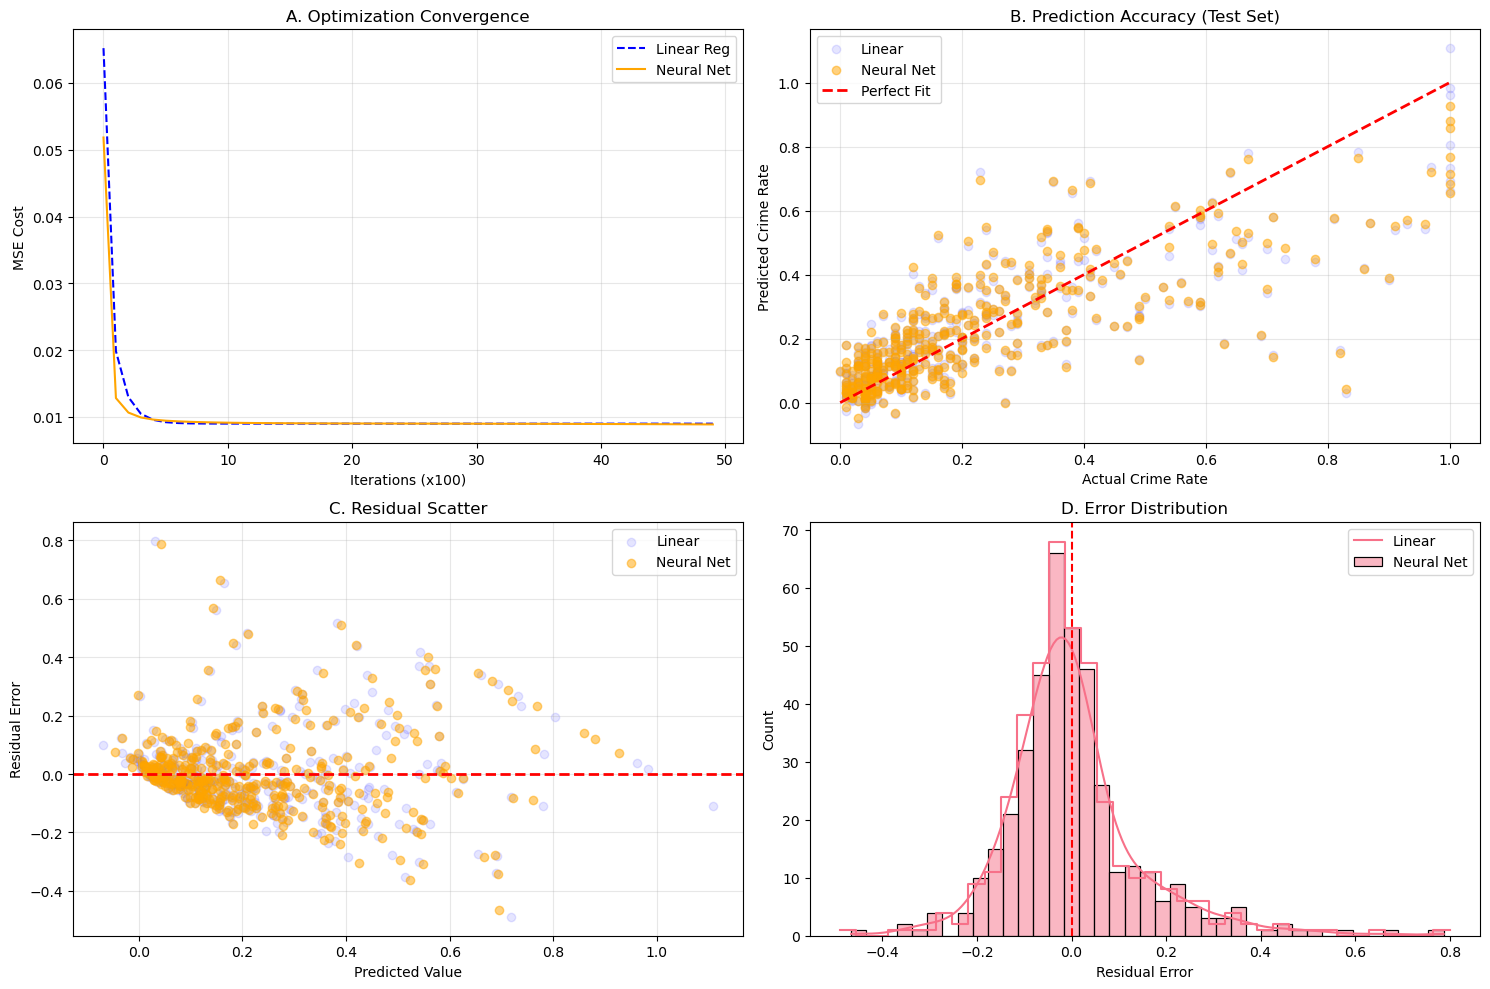

In [ ]:
# Train using full data
lr_params, lr_cost = train_linear_scratch(
    x_train_full, y_train_full,
    alpha=best_lr_alpha,
    num_iterations=5000
)

nn_params, nn_cost = train_nn_scratch(
    x_train_full, y_train_full,
    hidden_nodes=best_nn_nodes,
    alpha=best_nn_alpha,
    num_iterations=5000
)

# Train preds
lr_train_pred = predict_linear(x_train_full, lr_params)
nn_train_pred = predict_nn(x_train_full, nn_params)

# Test preds
lr_test_pred = predict_linear(x_test, lr_params)
nn_test_pred = predict_nn(x_test, nn_params)


# Results
print(f"\n{'Model':<20} | {'Train MSE':<10} | {'Test MSE':<10} | {'Train R2':<10} | {'Test R2':<10}")
print("-" * 75)

# Metrics Calculation
mse_lr_tr = mean_squared_error(y_train_full, lr_train_pred)
mse_lr_te = mean_squared_error(y_test, lr_test_pred)
r2_lr_tr = r2_score(y_train_full, lr_train_pred)
r2_lr_te = r2_score(y_test, lr_test_pred)
print(f"{'Linear Regression':<20} | {mse_lr_tr:.5f}    | {mse_lr_te:.5f}   | {r2_lr_tr:.5f}    | {r2_lr_te:.5f}")

mse_nn_tr = mean_squared_error(y_train_full, nn_train_pred)
mse_nn_te = mean_squared_error(y_test, nn_test_pred)
r2_nn_tr = r2_score(y_train_full, nn_train_pred)
r2_nn_te = r2_score(y_test, nn_test_pred)
print(f"{'Neural Network':<20} | {mse_nn_tr:.5f}    | {mse_nn_te:.5f}   | {r2_nn_tr:.5f}    | {r2_nn_te:.5f}")

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Optimization convergence graph
axes[0,0].plot(lr_cost, label='Linear Reg', color='blue', linestyle='--')
axes[0,0].plot(nn_cost, label='Neural Net', color='orange')
axes[0,0].set_title('A. Optimization Convergence')
axes[0,0].set_xlabel('Iterations (x100)')
axes[0,0].set_ylabel('MSE Cost')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Predicted vs Actual graph
axes[0,1].scatter(y_test, lr_test_pred, color='blue', alpha=0.1, label='Linear')
axes[0,1].scatter(y_test, nn_test_pred, color='orange', alpha=0.5, label='Neural Net')
axes[0,1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Fit')
axes[0,1].set_title('B. Prediction Accuracy (Test Set)')
axes[0,1].set_xlabel('Actual Crime Rate')
axes[0,1].set_ylabel('Predicted Crime Rate')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Residual Scatter graph
res_lr = y_test - lr_test_pred
res_nn = y_test - nn_test_pred
axes[1,0].scatter(lr_test_pred, res_lr, color='blue', alpha=0.1, label='Linear')
axes[1,0].scatter(nn_test_pred, res_nn, color='orange', alpha=0.5, label='Neural Net')
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('C. Residual Scatter')
axes[1,0].set_xlabel('Predicted Value')
axes[1,0].set_ylabel('Residual Error')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Residual Histogram graph
sns.histplot(res_lr, color='blue', element="step", fill=False, label='Linear', ax=axes[1,1])
sns.histplot(res_nn, color='orange', kde=True, label='Neural Net', ax=axes[1,1])
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title('D. Error Distribution')
axes[1,1].set_xlabel('Residual Error')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## Markov Decision Process

In [ ]:
# States represent community crime / safety levels
states = ['low_risk', 'moderate_risk', 'high_risk', 'critical']
terminal_state = 'critical'

# Actions represent possible interventions
actions = ['maintain', 'increase_patrols', 'invest_prevention']


transition_prob = {
    'low_risk': {
        'maintain': {
            'low_risk': 0.7,
            'moderate_risk': 0.3
        },
        'increase_patrols': {
            'low_risk': 0.8,
            'moderate_risk': 0.2
        },
        'invest_prevention': {
            'low_risk': 0.85,
            'moderate_risk': 0.15
        }
    },
    'moderate_risk': {
        'maintain': {
            'moderate_risk': 0.6,
            'high_risk': 0.4
        },
        'increase_patrols': {
            'low_risk': 0.4,
            'moderate_risk': 0.5,
            'high_risk': 0.1
        },
        'invest_prevention': {
            'low_risk': 0.5,
            'moderate_risk': 0.4,
            'high_risk': 0.1
        }
    },
    'high_risk': {
        'maintain': {
            'high_risk': 0.5,
            'critical': 0.5
        },
        'increase_patrols': {
            'moderate_risk': 0.5,
            'high_risk': 0.4,
            'critical': 0.1
        },
        'invest_prevention': {
            'moderate_risk': 0.6,
            'high_risk': 0.3,
            'critical': 0.1
        }
    },
    'critical': {
        # Terminal state, once in critical stop modelling transitions
        'maintain': {},
        'increase_patrols': {},
        'invest_prevention': {}
    }
}

# Reward function
rewards = {
    'low_risk': {
        'maintain': 5,
        'increase_patrols': 3,
        'invest_prevention': 4
    },
    'moderate_risk': {
        'maintain': -1,
        'increase_patrols': 2,
        'invest_prevention': 3
    },
    'high_risk': {
        'maintain': -5,
        'increase_patrols': 0,
        'invest_prevention': 1
    },
    'critical': {
        'maintain': -50,
        'increase_patrols': -50,
        'invest_prevention': -50
    }
}


gamma = 0.9
theta = 1e-4

V = {s: 0.0 for s in states}

def value_iteration():
    iteration = 0
    while True:
        delta = 0.0
        for s in states:
            if s == terminal_state:
                continue
            v_old = V[s]
            action_values = []
            for a in actions:
                total = 0.0
                for next_s, prob in transition_prob[s][a].items():
                    total += prob * V[next_s]
                q_sa = rewards[s][a] + gamma * total
                action_values.append(q_sa)
            V[s] = max(action_values)
            delta = max(delta, abs(v_old - V[s]))
        iteration += 1
        if delta < theta:
            break
    return V

def extract_policy(V_opt):
    policy = {}
    for s in states:
        if s == terminal_state:
            policy[s] = None
            continue
        action_values = {}
        for a in actions:
            total = 0.0
            for next_s, prob in transition_prob[s][a].items():
                total += prob * V_opt[next_s]
            action_values[a] = rewards[s][a] + gamma * total
        best_a = max(action_values, key=action_values.get)
        policy[s] = best_a
    return policy


optimal_values = value_iteration()
optimal_policy = extract_policy(optimal_values)

print("Optimal State Values (V*):")
for s in states:
    print(f"State {s:>13}: V* = {optimal_values[s]:6.3f}")

print("\nOptimal Policy (π*):")
for s in states:
    print(f"State {s:>13}: best action = {optimal_policy[s]}")


Optimal State Values (V*):
State      low_risk: V* = 40.923
State moderate_risk: V* = 37.561
State     high_risk: V* = 29.155
State      critical: V* =  0.000

Optimal Policy (π*):
State      low_risk: best action = maintain
State moderate_risk: best action = invest_prevention
State     high_risk: best action = invest_prevention
State      critical: best action = None
